In [8]:
import matplotlib.pyplot as plt
import numpy as np
import ffs_defs as ffs

In [9]:
Q2_array = np.linspace(0,3,100)

In [10]:
# Compute axial from conformal variable parameterization
tc = 9*(0.14**2) # 9 * m_pi ^2, value lifted from paper
gA = -1.2723 
a_list = [-0.759, 2.30, -0.6, -3.8, 2.3, 2.16, -0.896, -1.58, 0.823] # values from footnote 13 on page 12 of Meyer's Deuterium scattering paper
a_list_2 = [2.30, -0.6, -3.8, 2.3] 

a_std_dv_list = [.13, 1.0, 2.5, 2.7]
correlation_matrix = [[1, 0.350, -0.678, 0.611],
                      [0.350, 1, -0.898, 0.367],
                      [-0.678, -0.898, 1, -0.685],
                      [0.611, 0.367, -0.685, 1]]


axial_ff_conf_array = np.array([-ffs.axial_conf(Q2, tc, a_list) for Q2 in Q2_array])
axial_ff_conf_error_array = np.array([ffs.axial_conf_err(Q2, tc, a_list_2, a_std_dv_list, correlation_matrix,gA) for Q2 in Q2_array])

In [12]:
# Compute axial from dipole parameterization
mA = 1.014 
mA_std_dv = 0.014
axial_ff_dip_array = np.array([-ffs.axial_dipole(Q2, gA, mA) for Q2 in Q2_array])
axial_ff_dip_error_array = np.array([ffs.axial_dipole_err(Q2, gA, mA, mA_std_dv) for Q2 in Q2_array])

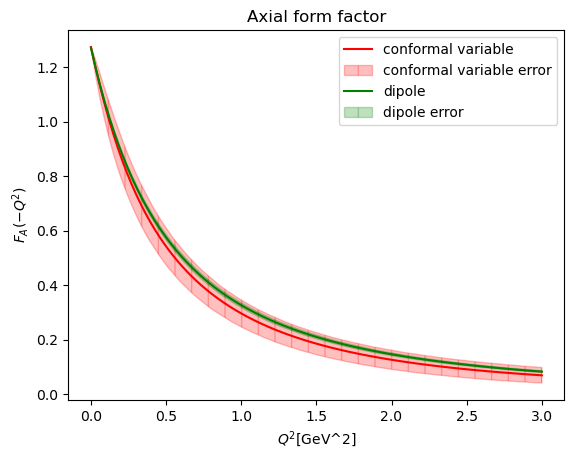

In [15]:
# Plot axial form factor
# -- conformal variable plot --
plt.plot(Q2_array, axial_ff_conf_array, label='conformal variable',color='red')
plt.fill_between(Q2_array, 
                 axial_ff_conf_array - axial_ff_conf_error_array, 
                 axial_ff_conf_array + axial_ff_conf_error_array,
                 label='conformal variable error', 
                 color='red', 
                 hatch='|',  # Vertical hatching
                 alpha=0.25)  # Semi-transparent fill

# -- dipole plot --
plt.plot(Q2_array, axial_ff_dip_array, label='dipole',color='green')
plt.fill_between(Q2_array, 
                 axial_ff_dip_array - axial_ff_dip_error_array, 
                 axial_ff_dip_array + axial_ff_dip_error_array,
                 label='dipole error', 
                 color='green', 
                 hatch='|',  # Vertical hatching
                 alpha=0.25)  # Semi-transparent fill
plt.title('Axial form factor')
plt.ylabel(r'$F_A(-Q^2)$')
plt.xlabel('$Q^2$[GeV^2]')
plt.legend()